Last edited: 1/28/2026, 3:38 PM CST
# Extreme event return periods as estimated by ERA5 and CMIP models

The idea is to compute return period curves for heat waves in famous locations (Paris, Seattle, Moscow) in the year they had famous heat waves (2003, 2021, 2010).

In [1]:
# import base packages for data analysis
import yaml

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

from evt_heat_waves.config import ERA5_PATH, MIP_FIT_PATH_DICT, MLE_FIT_ATTRS, EXT_DATA_PATH, CHECKS_PATH
from evt_heat_waves.plotting.return_rates import (
    make_event_location_checkplot, 
    get_return_level, 
    recenter_model_to_era5,
    plot_return_level_histogram_grid,
    summarize_return_levels,
)

from evt_heat_waves.utils import extract_model_name
from evt_heat_waves.mip_fit.cmip_dataclass import CMIP6EnsembleConfig
from evt_heat_waves.plotting.plotting_presets import get_presets

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

## Step 0: Set Data Attributes for Analysis

In [2]:
trend_vars = ['loc_t', 'scale_t', 'shape_t']

In [3]:
return_periods = np.array([
    2, 5, 10, 20, 50, 100, 200, 500, 1e3, 1e4
])

return_probs = 1 - return_periods**(-1)

In [4]:
# shared attributes
fit = 'nonstat_gumbel_only_loc_trend'  # from mle_attrs.yaml
anom_type = 'raw'  # must be raw
ex_type = 'max'  # max or min

# set anomaly type
data_type = 'raw' if anom_type == 'raw' else f"anom_{anom_type}"

In [5]:
# attributes of ERA5 data
TMIN = 1979  # 1979 or 1950
era5_variable = f't2m_annual_{ex_type}'
GRID = '1deg'

In [6]:
# attributes of CMIP data
cmip_variable = f'tas_annual_{ex_type}'
mip = 'cmip'  # amip or cmip

In [7]:
CMIPConfig = CMIP6EnsembleConfig.from_yaml(
    MIP_FIT_PATH_DICT[mip]['config']['meta'],
    MIP_FIT_PATH_DICT[mip]['config']['qc']
)

# make file/model matcher for 
data_path = MIP_FIT_PATH_DICT[mip]['data'] / cmip_variable / 'gev'

# Make all landonly file names
fnames = [f for f in data_path.glob(f"*_{fit}_*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results

modelname_filepath_matcher = {
    extract_model_name(f): f for f in fnames
}

## Step 1: Import ERA5 Data, heat wave location info, and Initialize Quantities of Interest for CMIP Comparison

In [8]:
# import ERA5 GEV characteristics
ds_era5 = xr.open_dataset(ERA5_PATH / 'gev' / f'era5_{era5_variable}_1deg_landonly_gev_{fit}_TMIN{TMIN}_{anom_type}.nc', engine='netcdf4')
PER_DECADE_CONVERSTION_FACTOR = 10 / len(ds_era5.year.values)

# import ERA5 temperatures 
ds_era5_temps = xr.open_dataset(ERA5_PATH / f'era5_t2m_annual_mean_1deg.nc')
ds_era5_temps_max = xr.open_dataset(ERA5_PATH / f'era5_t2m_annual_max_1deg.nc')

# store flattened, screened numpy arrays of ERA5 fit variables for regressions and bias calculations later
era5_data = {p: ds_era5[f'{p}_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
             if p in trend_vars
             else ds_era5[f'{p}_{data_type}'].values.flatten()
             for p in MLE_FIT_ATTRS[fit]['param_names']
}

In [9]:
ds_era5_temps_max

<xarray.Dataset>
Dimensions:  (lat: 180, lon: 360, year: 75)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2020 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float32 ...

In [10]:
# import event information
with open(EXT_DATA_PATH) as f:
    event_info = yaml.safe_load(f)

N_events = len(event_info.keys())

N_events, event_info

(9,
 {'Seattle': {'lat': 47.61,
   'lon': 237.61,
   'max_T_raw_obs': 42.0,
   'year': 2021},
  'Mexico City': {'lat': 19.43,
   'lon': 260.87,
   'max_T_raw_obs': 34.7,
   'year': 2024},
  'Sao Paulo': {'lat': -23.55,
   'lon': 313.37,
   'max_T_raw_obs': 37.0,
   'year': 2014},
  'Lyon': {'lat': 45.76, 'lon': 4.83, 'max_T_raw_obs': 40.5, 'year': 2003},
  'Lagos': {'lat': 6.45, 'lon': 3.42, 'max_T_raw_obs': 40.1, 'year': 2020},
  'New Delhi': {'lat': 28.61,
   'lon': 77.21,
   'max_T_raw_obs': 49.9,
   'year': 2024},
  'Moscow': {'lat': 55.75, 'lon': 37.62, 'max_T_raw_obs': 38.2, 'year': 2010},
  'Tokyo': {'lat': 35.69, 'lon': 139.69, 'max_T_raw_obs': 39.5, 'year': 2004},
  'Melbourne': {'lat': -37.81,
   'lon': 144.96,
   'max_T_raw_obs': 46.4,
   'year': 2009}})

Saved event location checkplot to /project/bbcael/ambauer/gev-heat-waves/analysis/figs/checks/2026-05-15-event_location_checks.png.png


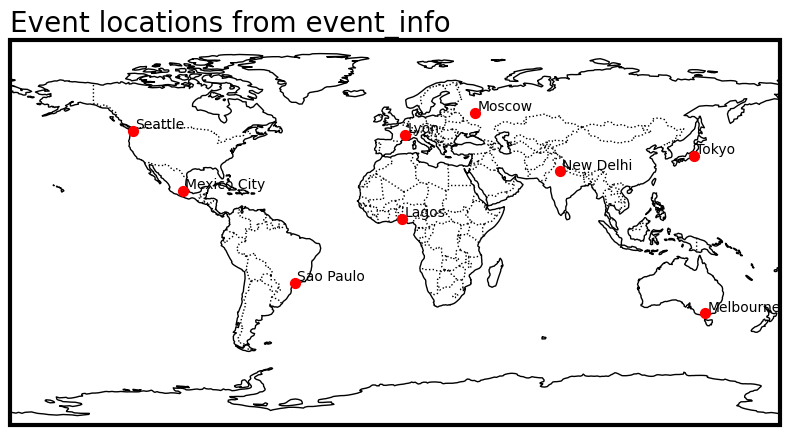

In [11]:
make_event_location_checkplot(event_info, save_figs,
                              fname='event_location_checks.png', outdir=CHECKS_PATH)

Setup for primary model member analysis.

In [12]:
# get number of models for this variable
N_active_models = len(
    list(m for m in CMIPConfig.iter_active_models(cmip_variable))
)

return_levels_prim = np.zeros(
    (N_events, N_active_models, len(return_periods))
)

Setup for analyzing the model with the most ensemble members (probably MIROC6 but there can be others).

In [13]:
# Calculate number of ensemble members for each active model
Nens_for_active_models = np.array([
    len(m.all_members) for m in CMIPConfig.iter_active_models(cmip_variable)
])

# Find model(s) with most members
max_inds = np.where(Nens_for_active_models == np.max(Nens_for_active_models))[0]

# Select first model with most members
ind_ = max_inds[0]
model_with_most = [m.name for m in CMIPConfig.iter_active_models(cmip_variable)][ind_]
N_members = np.max(Nens_for_active_models)

return_levels_most = np.zeros(
    (N_events, N_members, len(return_periods))
)

## Step 2: Loop Through CMIP Model with Most Members and Carry Out Fitting

## ERA5

In [14]:
era5_ret_levels = np.zeros((N_events, len(return_probs)))
era5_max_temp = np.zeros(N_events)
max_temp_year = np.zeros(N_events)

for edx, loc in enumerate(event_info.keys()):
    print(f"⚒️ Working on {loc}...")
    tmp_ds = ds_era5.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

    era5_max_temp[edx] = ds_era5_temps.sel(
        lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest'
    ).sel(
        year=event_info[loc]['year']
    ).t2m.values - 273.15

    NORM_YEAR = (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)

    tmp_loc = (tmp_ds[f'loc_{data_type}'].values.flatten() + tmp_ds[f'loc_t_{data_type}'].values.flatten() * NORM_YEAR
               if 'loc_t' in MLE_FIT_ATTRS[fit]['param_names']
               else tmp_ds[f'loc_{data_type}'].values.flatten())
    tmp_scale = (tmp_ds[f'scale_{data_type}'].values.flatten() + tmp_ds[f'scale_t_{data_type}'].values.flatten() * NORM_YEAR
                 if 'scale_t' in MLE_FIT_ATTRS[fit]['param_names']
                 else tmp_ds[f'scale_{data_type}'].values.flatten())
    
    try:
        tmp_shape = (tmp_ds[f'shape_{data_type}'].values.flatten() + tmp_ds[f'shape_t_{data_type}'].values.flatten() * NORM_YEAR
                    if 'shape_t' in MLE_FIT_ATTRS[fit]['param_names']
                    else tmp_ds[f'shape_{data_type}'].values.flatten())
        
    except KeyError:
        # set shape value based on the constraint
        for cons in MLE_FIT_ATTRS[fit]['constraints']:
            if cons['params'][0] == 'shape':
                tmp_shape = cons['value']

    print(f"    # ERA5 GEV parameters in the event year, {event_info[loc]['year']}: {tmp_loc, tmp_scale, tmp_shape}")

    era5_ret_levels[edx] = get_return_level(return_probs, tmp_loc, tmp_scale, tmp_shape)

    tmp_ds.close()

⚒️ Working on Seattle...
    # ERA5 GEV parameters in the event year, 2021: (array([295.22387119]), array([1.49201385]), -0.0001)
⚒️ Working on Mexico City...
    # ERA5 GEV parameters in the event year, 2024: (array([291.74994969]), array([0.69014266]), -0.0001)
⚒️ Working on Sao Paulo...
    # ERA5 GEV parameters in the event year, 2014: (array([298.55671344]), array([0.68032353]), -0.0001)
⚒️ Working on Lyon...
    # ERA5 GEV parameters in the event year, 2003: (array([297.85579817]), array([1.28692821]), -0.0001)
⚒️ Working on Lagos...
    # ERA5 GEV parameters in the event year, 2020: (array([301.56026878]), array([0.20688843]), -0.0001)
⚒️ Working on New Delhi...
    # ERA5 GEV parameters in the event year, 2024: (array([310.24998539]), array([0.87897077]), -0.0001)
⚒️ Working on Moscow...
    # ERA5 GEV parameters in the event year, 2010: (array([296.30816619]), array([1.16083363]), -0.0001)
⚒️ Working on Tokyo...
    # ERA5 GEV parameters in the event year, 2004: (array([300.63

In [15]:
for loc in event_info.keys():
    diff = ds_era5_temps_max.sel(
        lat=event_info[loc]['lat'],
        lon=event_info[loc]['lon'],
        method='nearest'
    ).sel(
        year=event_info[loc]['year']
    ).t2m.values - 273.15 - event_info[loc]['max_T_raw_obs']
    
    print(f"{loc} {diff}")

print(era5_max_temp)


Seattle -12.482733154296852
Mexico City -12.16640624999998
Sao Paulo -9.024999999999977
Lyon -10.436346435546852
Lagos -10.489471435546854
New Delhi -9.886364746093726
Moscow -7.907952880859355
Tokyo -9.215551757812477
Melbourne -12.921215820312476
[ 9.73391113 16.40532837 20.93483887 12.86345825 27.11123047 26.71352539
  6.32525024 16.76253662 13.90801392]


## All members of most_mems

In [16]:
# Find all 'allmems' GEV files for the chosen model and anomaly type
gev_dir = MIP_FIT_PATH_DICT[mip]['data'] / cmip_variable / 'gev'
pattern = f"*{model_with_most}*_{fit}_*allmems*{anom_type}.nc"
allmems_files = sorted(gev_dir.glob(pattern))
print(f"Found {len(allmems_files)} files matching: {pattern}")
for p in allmems_files:
    print(p.name)

# expose the list for later use
allmems_filepaths = allmems_files

Found 1 files matching: *MIROC6*_nonstat_gumbel_only_loc_trend_*allmems*raw.nc
tas_CMIP6_MIROC6_day_hist+ssp585_1850-2015_landonly_gev_nonstat_gumbel_only_loc_trend_allmems_raw.nc


Loop through "most member" model.

In [17]:
# percentiles for masking
plo = 5
phi = 95

MAKE_CHECKS = False

ds = xr.open_dataset(allmems_filepaths[0], engine='netcdf4')

for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on the heat wave in {loc}")

    for idx, mem in enumerate(ds.member_id.values):
        print(f"    ⚒️ Working on member: {mem}")

        # do this for each location
        tmp_ds = ds.sel(member_id=mem)
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=model_with_most, member_id=mem, mip=mip,
                                        time_interval=slice(1979, 2000))

        # carry out calculations for both nonstationary and stationary cases
        NORM_YEAR = (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)

        tmp_loc = (tmp_ds[f'loc_{data_type}'].values.flatten() + tmp_ds[f'loc_t_{data_type}'].values.flatten() * NORM_YEAR
                if 'loc_t' in MLE_FIT_ATTRS[fit]['param_names']
                else tmp_ds[f'loc_{data_type}'].values.flatten())
        tmp_scale = (tmp_ds[f'scale_{data_type}'].values.flatten() + tmp_ds[f'scale_t_{data_type}'].values.flatten() * NORM_YEAR
                    if 'scale_t' in MLE_FIT_ATTRS[fit]['param_names']
                    else tmp_ds[f'scale_{data_type}'].values.flatten())
        try:
            tmp_shape = (tmp_ds[f'shape_{data_type}'].values.flatten() + tmp_ds[f'shape_t_{data_type}'].values.flatten() * NORM_YEAR
                        if 'shape_t' in MLE_FIT_ATTRS[fit]['param_names']
                        else tmp_ds[f'shape_{data_type}'].values.flatten())
            
        except KeyError:
            # set shape value based on the constraint
            for cons in MLE_FIT_ATTRS[fit]['constraints']:
                if cons['params'][0] == 'shape':
                    tmp_shape = cons['value']
        
        if np.isnan(tmp_loc) or np.isnan(tmp_scale) or np.isnan(tmp_shape):
            import warnings
            warnings.warn(f"Warning: NaN values found in GEV parameters for {model_with_most} member {mem} at location {loc}. Skipping.")
            return_levels_most[edx, idx] = np.nan * np.ones_like(return_periods)
        
        else:
            return_levels_most[edx, idx] = get_return_level(return_probs, tmp_loc, tmp_scale, tmp_shape) + offset

        tmp_ds.close()


 🔥 Working on the heat wave in Seattle


    ⚒️ Working on member: MIROC6_r10i1p1f1
    ⚒️ Working on member: MIROC6_r8i1p1f1
    ⚒️ Working on member: MIROC6_r11i1p1f1
    ⚒️ Working on member: MIROC6_r9i1p1f1
    ⚒️ Working on member: MIROC6_r12i1p1f1
    ⚒️ Working on member: MIROC6_r13i1p1f1
    ⚒️ Working on member: MIROC6_r14i1p1f1
    ⚒️ Working on member: MIROC6_r15i1p1f1
    ⚒️ Working on member: MIROC6_r16i1p1f1
    ⚒️ Working on member: MIROC6_r17i1p1f1
    ⚒️ Working on member: MIROC6_r18i1p1f1
    ⚒️ Working on member: MIROC6_r19i1p1f1
    ⚒️ Working on member: MIROC6_r1i1p1f1
    ⚒️ Working on member: MIROC6_r20i1p1f1
    ⚒️ Working on member: MIROC6_r21i1p1f1
    ⚒️ Working on member: MIROC6_r22i1p1f1
    ⚒️ Working on member: MIROC6_r23i1p1f1
    ⚒️ Working on member: MIROC6_r24i1p1f1
    ⚒️ Working on member: MIROC6_r25i1p1f1
    ⚒️ Working on member: MIROC6_r26i1p1f1
    ⚒️ Working on member: MIROC6_r27i1p1f1
    ⚒️ Working on member: MIROC6_r28i1p1f1
    ⚒️ Working on member: MIROC6_r29i1p1f1
    ⚒️ Workin

## Primary members for all CMIP models

In [18]:
# percentiles for masking
plo = 5
phi = 95

# loop through models 
for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on the heat wave in {loc}")
    
    for (idx, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
        print(f"    ⚒️ Working on {m.name}...")

        # open dataset
        tmp_ds = xr.open_dataset(
            modelname_filepath_matcher[m.name]
        )

        # do this for each location
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=model_with_most, member_id=mem, mip=mip,
                                        time_interval=slice(1979, 2000))

        # carry out calculations for both nonstationary and stationary cases
        NORM_YEAR = (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)

        tmp_loc = (tmp_ds[f'loc_{data_type}'].values.flatten() + tmp_ds[f'loc_t_{data_type}'].values.flatten() * NORM_YEAR
                   if 'loc_t' in MLE_FIT_ATTRS[fit]['param_names']
                   else tmp_ds[f'loc_{data_type}'].values.flatten())
        tmp_scale = (tmp_ds[f'scale_{data_type}'].values.flatten() + tmp_ds[f'scale_t_{data_type}'].values.flatten() * NORM_YEAR
                    if 'scale_t' in MLE_FIT_ATTRS[fit]['param_names']
                    else tmp_ds[f'scale_{data_type}'].values.flatten())
        try:
            tmp_shape = (tmp_ds[f'shape_{data_type}'].values.flatten() + tmp_ds[f'shape_t_{data_type}'].values.flatten() * NORM_YEAR
                        if 'shape_t' in MLE_FIT_ATTRS[fit]['param_names']
                        else tmp_ds[f'shape_{data_type}'].values.flatten())
            
        except KeyError:
            # set shape value based on the constraint
            for cons in MLE_FIT_ATTRS[fit]['constraints']:
                if cons['params'][0] == 'shape':
                    tmp_shape = cons['value']
        
        if np.isnan(tmp_loc) or np.isnan(tmp_scale) or np.isnan(tmp_shape):
            import warnings
            warnings.warn(f"Warning: NaN values found in GEV parameters for {model_with_most} member {mem} at location {loc}. Skipping.")
            return_levels_prim[edx, idx] = np.nan * np.ones_like(return_periods)
        
        else:
            return_levels_prim[edx, idx] = get_return_level(return_probs, tmp_loc, tmp_scale, tmp_shape) + offset

        tmp_ds.close()



 🔥 Working on the heat wave in Seattle
    ⚒️ Working on AWI-CM-1-1-MR...
    ⚒️ Working on BCC-CSM2-MR...
    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...

 🔥 Working 

# Plotting

In [19]:
# max temperature based on station data
max_temps = {
    loc: event_info[loc]['max_T_raw_obs'] for loc in event_info.keys()
}

plot_return_levels_obs(
    event_info, CMIPConfig,
    return_periods, max_temps,
    era5_ret_levels, return_levels_prim, return_levels_most,
    model_with_most, anom_type, cmip_variable, save_figs,
    fname=f'return_levels_obs_{anom_type}_{fit}', outdir=FIGS_PATH
)

NameError: name 'plot_return_levels_obs' is not defined

✍️ Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-05-15-return_levels_era5_raw_nonstat_gumbel_only_loc_trend.png


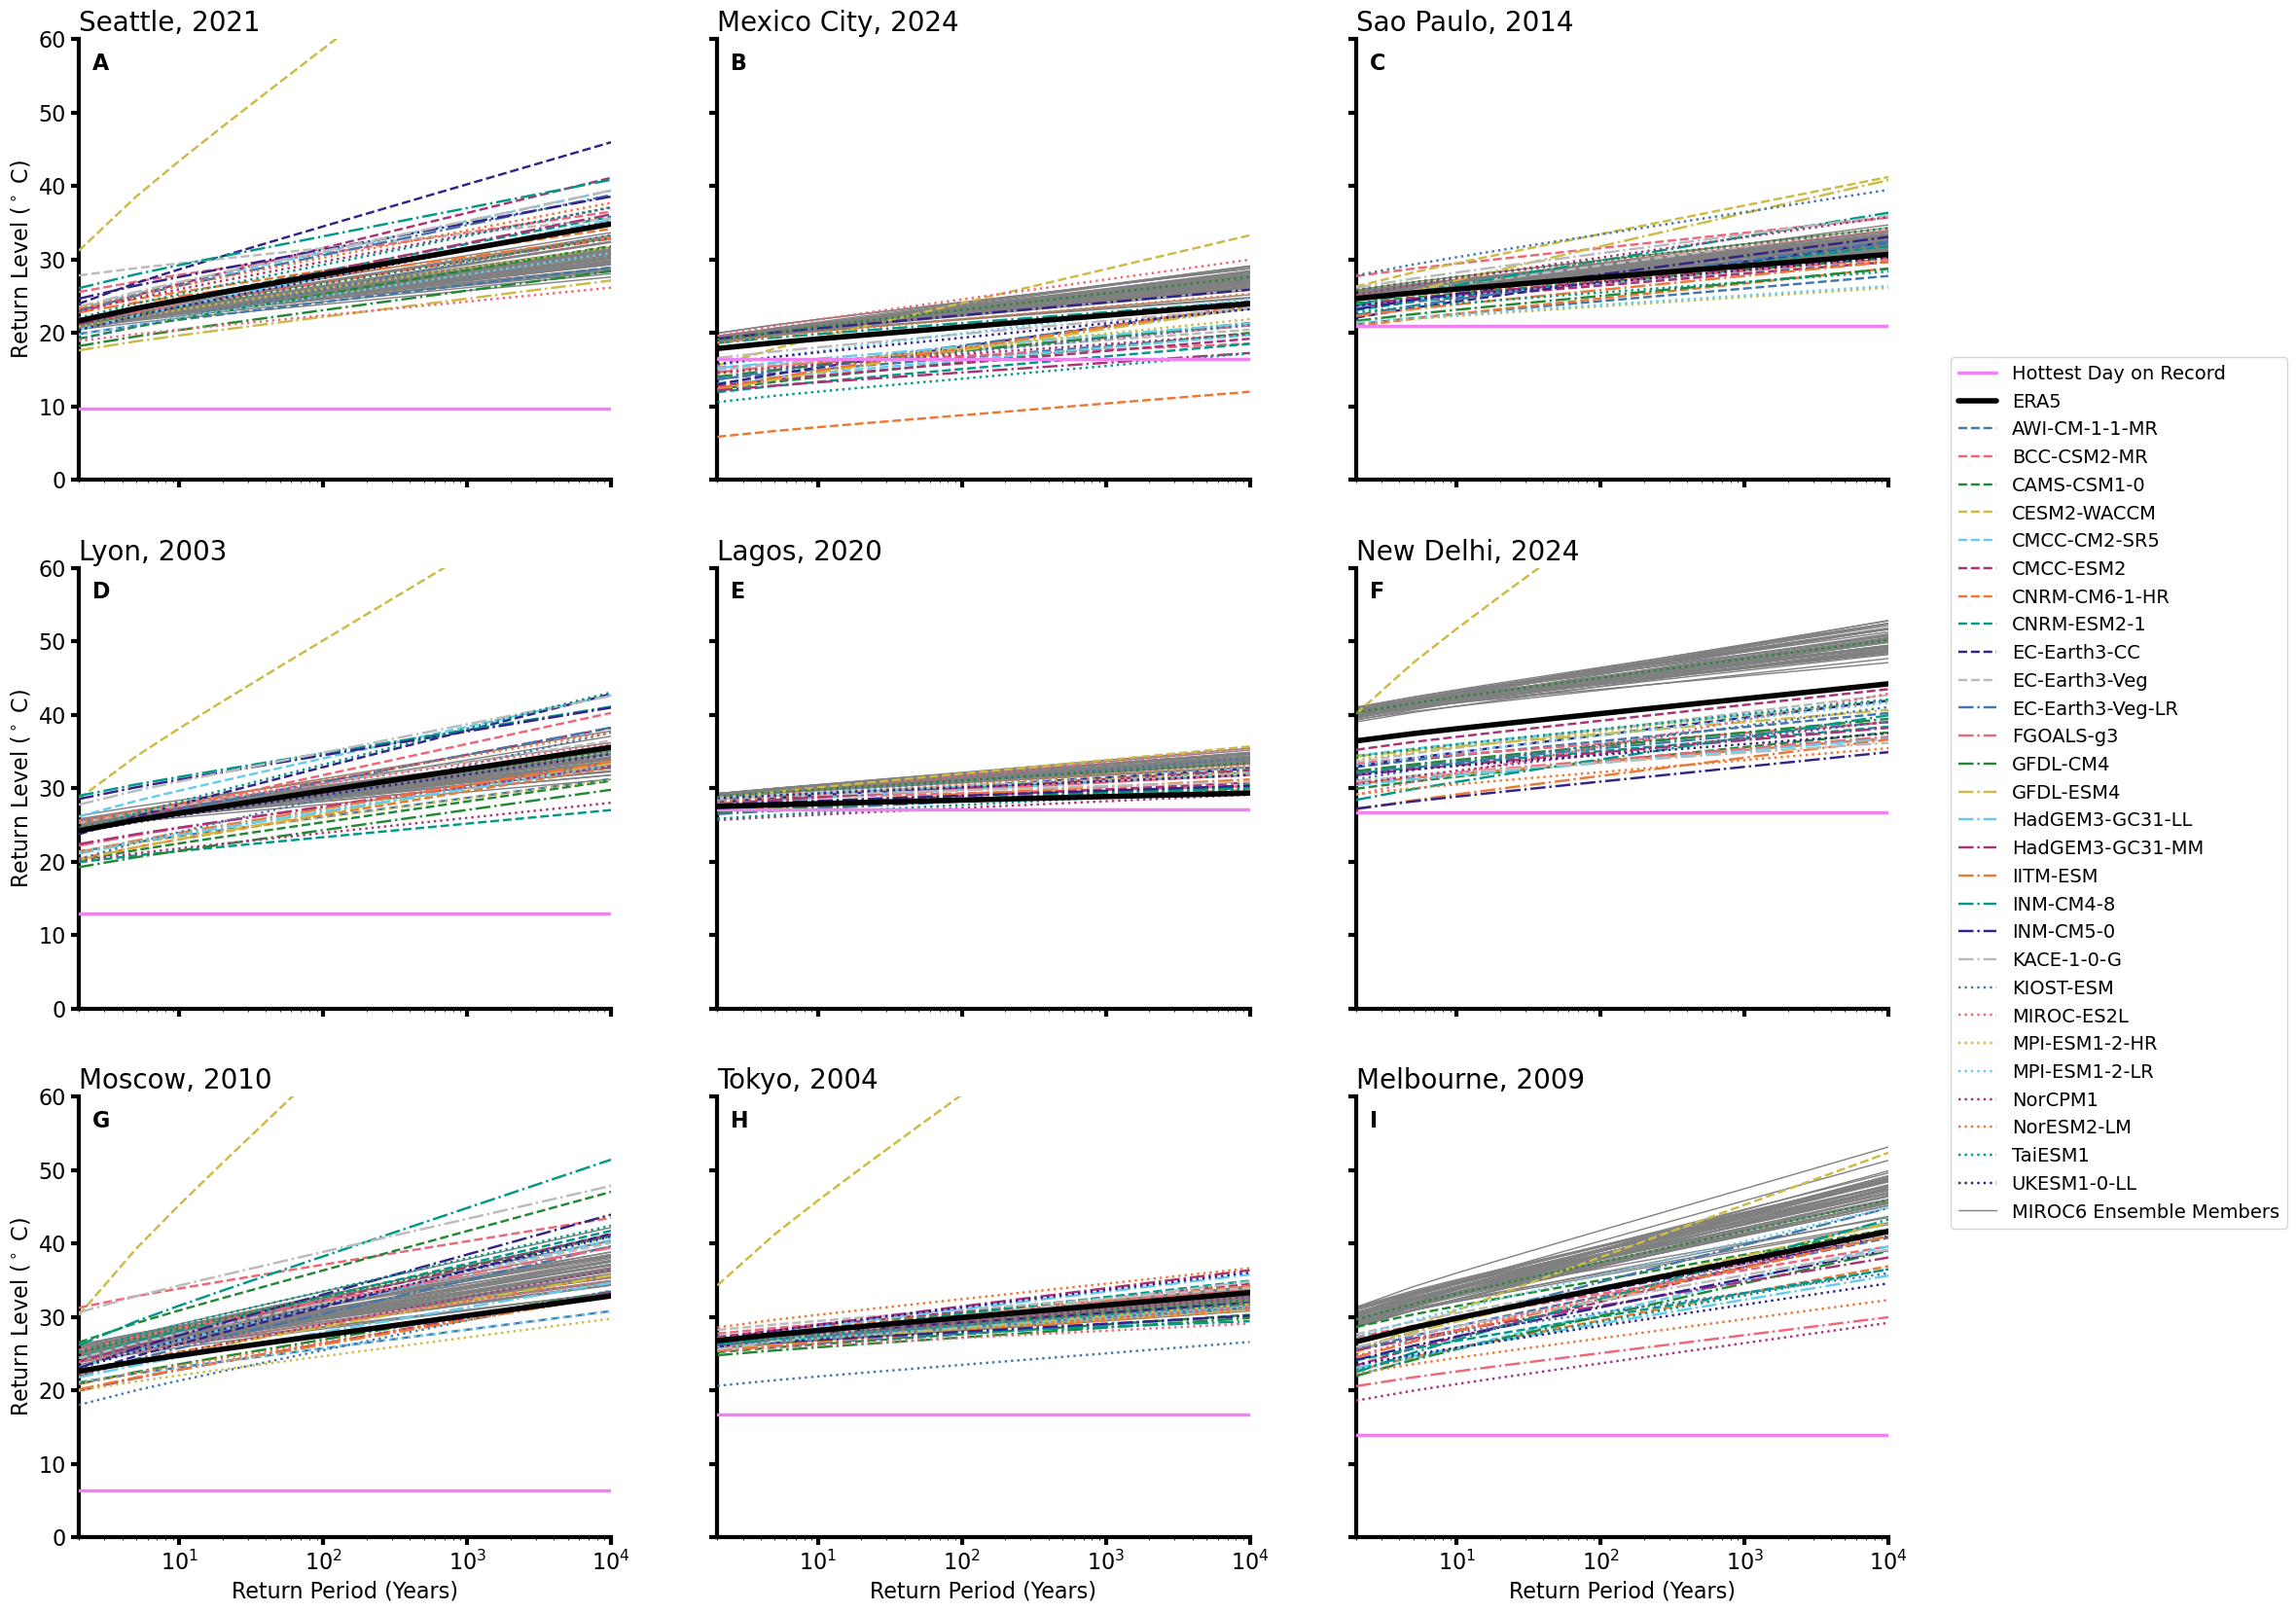

In [ ]:
# max temperature based on station data
max_temps = {
    loc: era5_max_temp[edx] for edx, loc in enumerate(event_info.keys())
}

plot_return_levels_obs(
    event_info, CMIPConfig,
    return_periods, max_temps,
    era5_ret_levels, return_levels_prim, return_levels_most,
    model_with_most, anom_type, cmip_variable, save_figs,
    fname=f'return_levels_era5_{anom_type}_{fit}', outdir=FIGS_PATH
)

✍️ Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-05-15-return_level_kde_nonstat_gumbel_only_loc_trend_prims.png


(<Figure size 1600x1200 with 6 Axes>,
 array([<Axes: title={'left': 'Seattle'}, ylabel='Density'>,
        <Axes: title={'left': 'Sao Paulo'}>,
        <Axes: title={'left': 'Lyon'}, ylabel='Density'>,
        <Axes: title={'left': 'New Delhi'}>,
        <Axes: title={'left': 'Moscow'}, xlabel='Return Level (°C)', ylabel='Density'>,
        <Axes: title={'left': 'Melbourne'}, xlabel='Return Level (°C)'>],
       dtype=object))

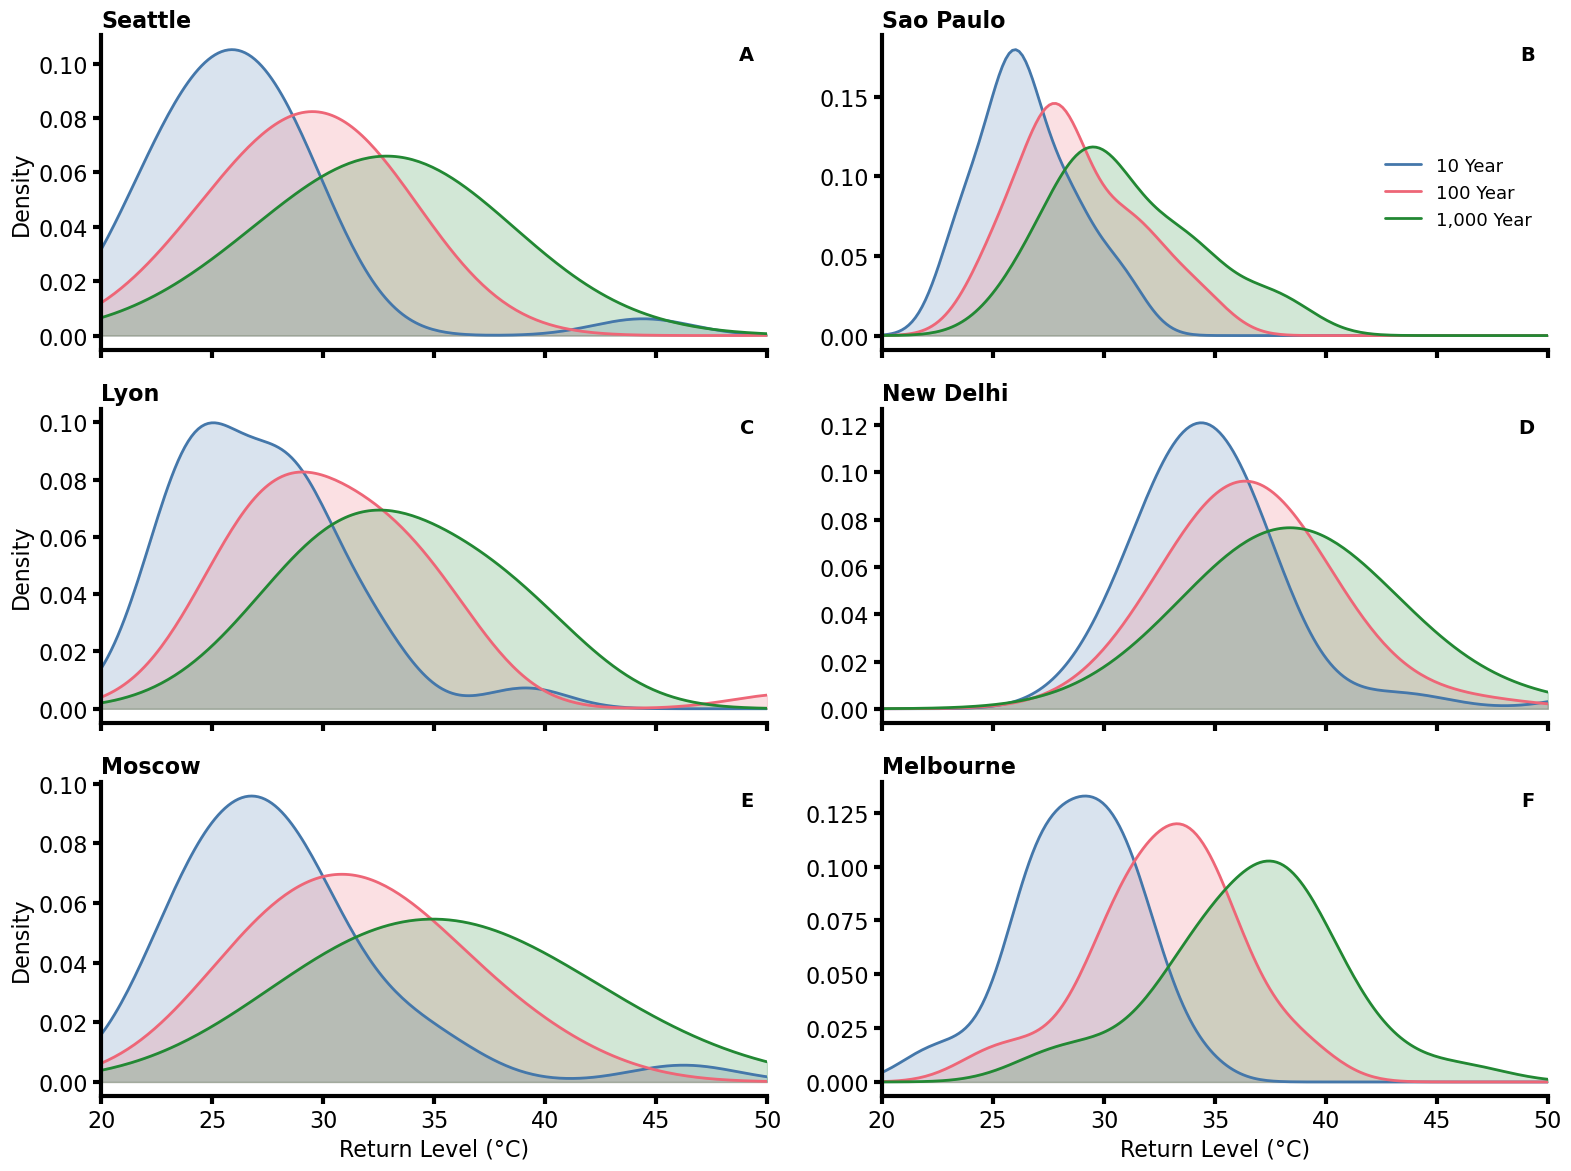

In [ ]:
event_indices = [0, 2, 3, 5, 6, 8]

plot_return_level_histogram_grid(
    return_levels_prim,
    return_period_list=[10, 100, 1000],
    event_indices=event_indices,
    return_periods=return_periods,
    event_names=np.array([loc for loc in event_info.keys()]),
    plot_type='kde',
    save_fig=save_figs,
    fname=f'return_level_kde_{fit}_prims',
    outdir=FIGS_PATH
)

## Return Level Summary Statistics

The `summarize_return_levels()` function prints a formatted table of return level statistics for each location and return period. For each location and return period, it displays:
- **5th %ile**: 5th percentile of model return levels (°C)
- **Median**: 50th percentile (°C)
- **Mean**: Average return level across models (°C)
- **95th %ile**: 95th percentile of model return levels (°C)
- **5-95 Range**: Difference between 95th and 5th percentiles, showing the interquartile spread (°C)

This is useful for understanding the range of uncertainty across the ensemble of models.

In [20]:
# Print return level summary for primary members at 10, 100, and 1000-year return periods
# Find the indices for these return periods
idx_10yr = int(np.where(return_periods == 10)[0][0])
idx_100yr = int(np.where(return_periods == 100)[0][0])
idx_1000yr = int(np.where(return_periods == 1000)[0][0])

summarize_return_levels(
    return_levels_prim,
    return_period_indices=[idx_10yr, idx_100yr, idx_1000yr],
    return_periods=return_periods,
    event_info=event_info,
    event_names=list(event_info.keys()),
    model_type='primary member'
)


Return Level Summary (primary member ensemble)

Seattle
------------------------------------------------------------------------------------------------------------------------
  Return Period        5th %ile          Median            Mean       95th %ile      5-95 Range
------------------------------------------------------------------------------------------------------------------------
        10-year           21.38           25.95           26.36           30.35            8.97
       100-year           23.64           29.37           30.25           34.94           11.30
      1000-year           26.08           33.08           34.07           39.92           13.84

Mexico City
------------------------------------------------------------------------------------------------------------------------
  Return Period        5th %ile          Median            Mean       95th %ile      5-95 Range
---------------------------------------------------------------------------------------

In [30]:
# Example: Print summary for just a few locations to see cleaner output
subset_locations = [0, 2, 4]  # Paris, Moscow, and one other
subset_event_names = [list(event_info.keys())[i] for i in subset_locations]

summarize_return_levels(
    return_levels_prim,
    return_period_indices=[idx_10yr, idx_100yr, idx_1000yr],
    return_periods=return_periods,
    event_info=event_info,
    event_names=subset_event_names[:len(subset_locations)],
    model_type='primary member'
)


Return Level Summary (primary member ensemble)

Seattle
----------------------------------------------------------------------------------------------------
  Return Period        5th %ile          Median            Mean       95th %ile
----------------------------------------------------------------------------------------------------
        10-year           21.38           25.95           26.36           30.35
       100-year           23.64           29.37           30.25           34.94
      1000-year           26.08           33.08           34.07           39.92

Sao Paulo
----------------------------------------------------------------------------------------------------
  Return Period        5th %ile          Median            Mean       95th %ile
----------------------------------------------------------------------------------------------------
        10-year           13.48           16.67           17.07           21.74
       100-year           15.08           18.66 

In [ ]:
# You can also use this with the ensemble members data
# summarize_return_levels(
#     return_levels_most,
#     return_period_indices=[idx_10yr, idx_100yr, idx_1000yr],
#     return_periods=return_periods,
#     event_info=event_info,
#     event_names=subset_event_names[:len(subset_locations)],
#     model_type='all ensemble members'
# )

# OLD

# Plot 2: 100-year heat wave trend
The idea is to compute the 100-year return level from 1979 -> 2024 using the GEV fits that we have. Should be relatively easy. (Though you never know...)

In [29]:
np.shape(return_levels_most)

(9, 50, 15)

In [50]:
# set global attributes of analysis
EVENT_PERIOD = 10.  # set return period
years = np.arange(1979, 2025, 1)  # years to analyze

# empty arrays to fill later
event_level_trend_most = np.zeros([
    *np.shape(return_levels_most)[:-1], len(years)
])

event_level_trend_prim = np.zeros([
    *np.shape(return_levels_prim)[:-1], len(years)
])

Most members analysis.

In [ ]:
# open dataset
ds = xr.open_dataset(allmems_filepaths[0], engine='netcdf4')

for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on {loc}...")

    for idx, mem in enumerate(ds.member_id.values):
        print(f"    ⚒️ Working on member: {mem}")

        # do this for each location
        tmp_ds = ds.sel(member_id=mem)
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=model_with_most, member_id=mem)

        # carry out calculations for both nonstationary and stationary cases
        if fit == 'nonstat':
            # extract model variables
            m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
            m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
            m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

            if (np.isnan(m_loc) or np.isnan(m_loc_trend)
                or np.isnan(m_scale) or np.isnan(m_scale_trend)
                or np.isnan(m_shape) or np.isnan(m_shape_trend)):
                warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")
                event_level_trend_most[edx, idx] = np.array([np.nan] * len(years))

            else:
                event_level_trend_most[edx, idx] = np.array([
                    get_return_level(1/EVENT_PERIOD,
                                     m_loc + m_loc_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                     m_scale + m_scale_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                     m_shape + m_shape_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN))[0] + offset - 273.15
                    for yr in years
                ])

        else:
            import warnings
            warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")


 🔥 Working on Seattle...
    ⚒️ Working on member: MIROC6_r10i1p1f1
    ⚒️ Working on member: MIROC6_r8i1p1f1
    ⚒️ Working on member: MIROC6_r11i1p1f1
    ⚒️ Working on member: MIROC6_r9i1p1f1
    ⚒️ Working on member: MIROC6_r12i1p1f1
    ⚒️ Working on member: MIROC6_r13i1p1f1
    ⚒️ Working on member: MIROC6_r14i1p1f1
    ⚒️ Working on member: MIROC6_r15i1p1f1
    ⚒️ Working on member: MIROC6_r16i1p1f1
    ⚒️ Working on member: MIROC6_r17i1p1f1
    ⚒️ Working on member: MIROC6_r18i1p1f1
    ⚒️ Working on member: MIROC6_r19i1p1f1
    ⚒️ Working on member: MIROC6_r1i1p1f1
    ⚒️ Working on member: MIROC6_r20i1p1f1
    ⚒️ Working on member: MIROC6_r21i1p1f1
    ⚒️ Working on member: MIROC6_r22i1p1f1
    ⚒️ Working on member: MIROC6_r23i1p1f1
    ⚒️ Working on member: MIROC6_r24i1p1f1
    ⚒️ Working on member: MIROC6_r25i1p1f1
    ⚒️ Working on member: MIROC6_r26i1p1f1
    ⚒️ Working on member: MIROC6_r27i1p1f1
    ⚒️ Working on member: MIROC6_r28i1p1f1
    ⚒️ Working on member: MIROC

/scratch/local/jobs/47619552/ipykernel_1928717/3260403412.py:28: UserWarning: Member MIROC6_r32i1p1f1 skipped for event in Sao Paulo because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on member: MIROC6_r34i1p1f1
    ⚒️ Working on member: MIROC6_r35i1p1f1
    ⚒️ Working on member: MIROC6_r36i1p1f1
    ⚒️ Working on member: MIROC6_r37i1p1f1
    ⚒️ Working on member: MIROC6_r38i1p1f1
    ⚒️ Working on member: MIROC6_r39i1p1f1
    ⚒️ Working on member: MIROC6_r3i1p1f1
    ⚒️ Working on member: MIROC6_r40i1p1f1
    ⚒️ Working on member: MIROC6_r41i1p1f1
    ⚒️ Working on member: MIROC6_r42i1p1f1
    ⚒️ Working on member: MIROC6_r43i1p1f1
    ⚒️ Working on member: MIROC6_r44i1p1f1
    ⚒️ Working on member: MIROC6_r45i1p1f1
    ⚒️ Working on member: MIROC6_r46i1p1f1
    ⚒️ Working on member: MIROC6_r47i1p1f1
    ⚒️ Working on member: MIROC6_r48i1p1f1
    ⚒️ Working on member: MIROC6_r49i1p1f1
    ⚒️ Working on member: MIROC6_r4i1p1f1
    ⚒️ Working on member: MIROC6_r50i1p1f1
    ⚒️ Working on member: MIROC6_r5i1p1f1
    ⚒️ Working on member: MIROC6_r6i1p1f1
    ⚒️ Working on member: MIROC6_r7i1p1f1

 🔥 Working on Lyon...
    ⚒️ Working on member: MIROC6_r10

In [ ]:
# loop through models 
for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on {loc}")
    
    for (idx, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
        print(f"    ⚒️ Working on {m.name}...")

        # open dataset
        tmp_ds = xr.open_dataset(
            modelname_filepath_matcher[m.name]
        )

        # do this for each location
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=m.name, member_id=m.primary_member)

        # carry out calculations for both nonstationary and stationary cases
        if fit == 'nonstat':
            # extract model variables
            m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
            m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
            m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

            if (np.isnan(m_loc) or np.isnan(m_loc_trend)
                or np.isnan(m_scale) or np.isnan(m_scale_trend)
                or np.isnan(m_shape) or np.isnan(m_shape_trend)):
                warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")
                event_level_trend_prim[edx, idx] = np.array([np.nan] * len(years))

            else:
                # threshold check on scale parameter 
                if m_scale < 1e-2:
                    warnings.warn(f"Model {m.name} skipped for event in {loc} because the scale parameter is unreasonably small")
                    return_levels_prim[edx, idx] = np.array([np.nan] * len(return_probs))

                else:
                    event_level_trend_prim[edx, idx] = np.array([
                        get_return_level(1/EVENT_PERIOD,
                                        m_loc + m_loc_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                        m_scale + m_scale_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                        m_shape + m_shape_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN))[0] + offset - 273.15
                        for yr in years
                    ])

        else:
            import warnings
            warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

        tmp_ds.close()


 🔥 Working on Seattle
    ⚒️ Working on AWI-CM-1-1-MR...


    ⚒️ Working on BCC-CSM2-MR...
    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...


/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:30: UserWarning: Member MIROC6_r7i1p1f1 skipped for event in Seattle because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...

 🔥 Working on Mexico City
    ⚒️ Working on AWI-CM-1-1-MR...
    ⚒️ Working on BCC-CSM2-MR...
    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-E

/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:30: UserWarning: Member MIROC6_r7i1p1f1 skipped for event in Lyon because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


...

    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...


/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:36: UserWarning: Model EC-Earth3-Veg skipped for event in Tokyo because the scale parameter is unreasonably small
  warnings.warn(f"Model {m.name} skipped for event in {loc} because the scale parameter is unreasonably small")


    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...

 🔥 Working on Melbourne
    ⚒️ Working on AWI-CM-1-1-MR...
    ⚒️ Working on BCC-CSM2-MR...


/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:30: UserWarning: Member MIROC6_r7i1p1f1 skipped for event in Melbourne because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...


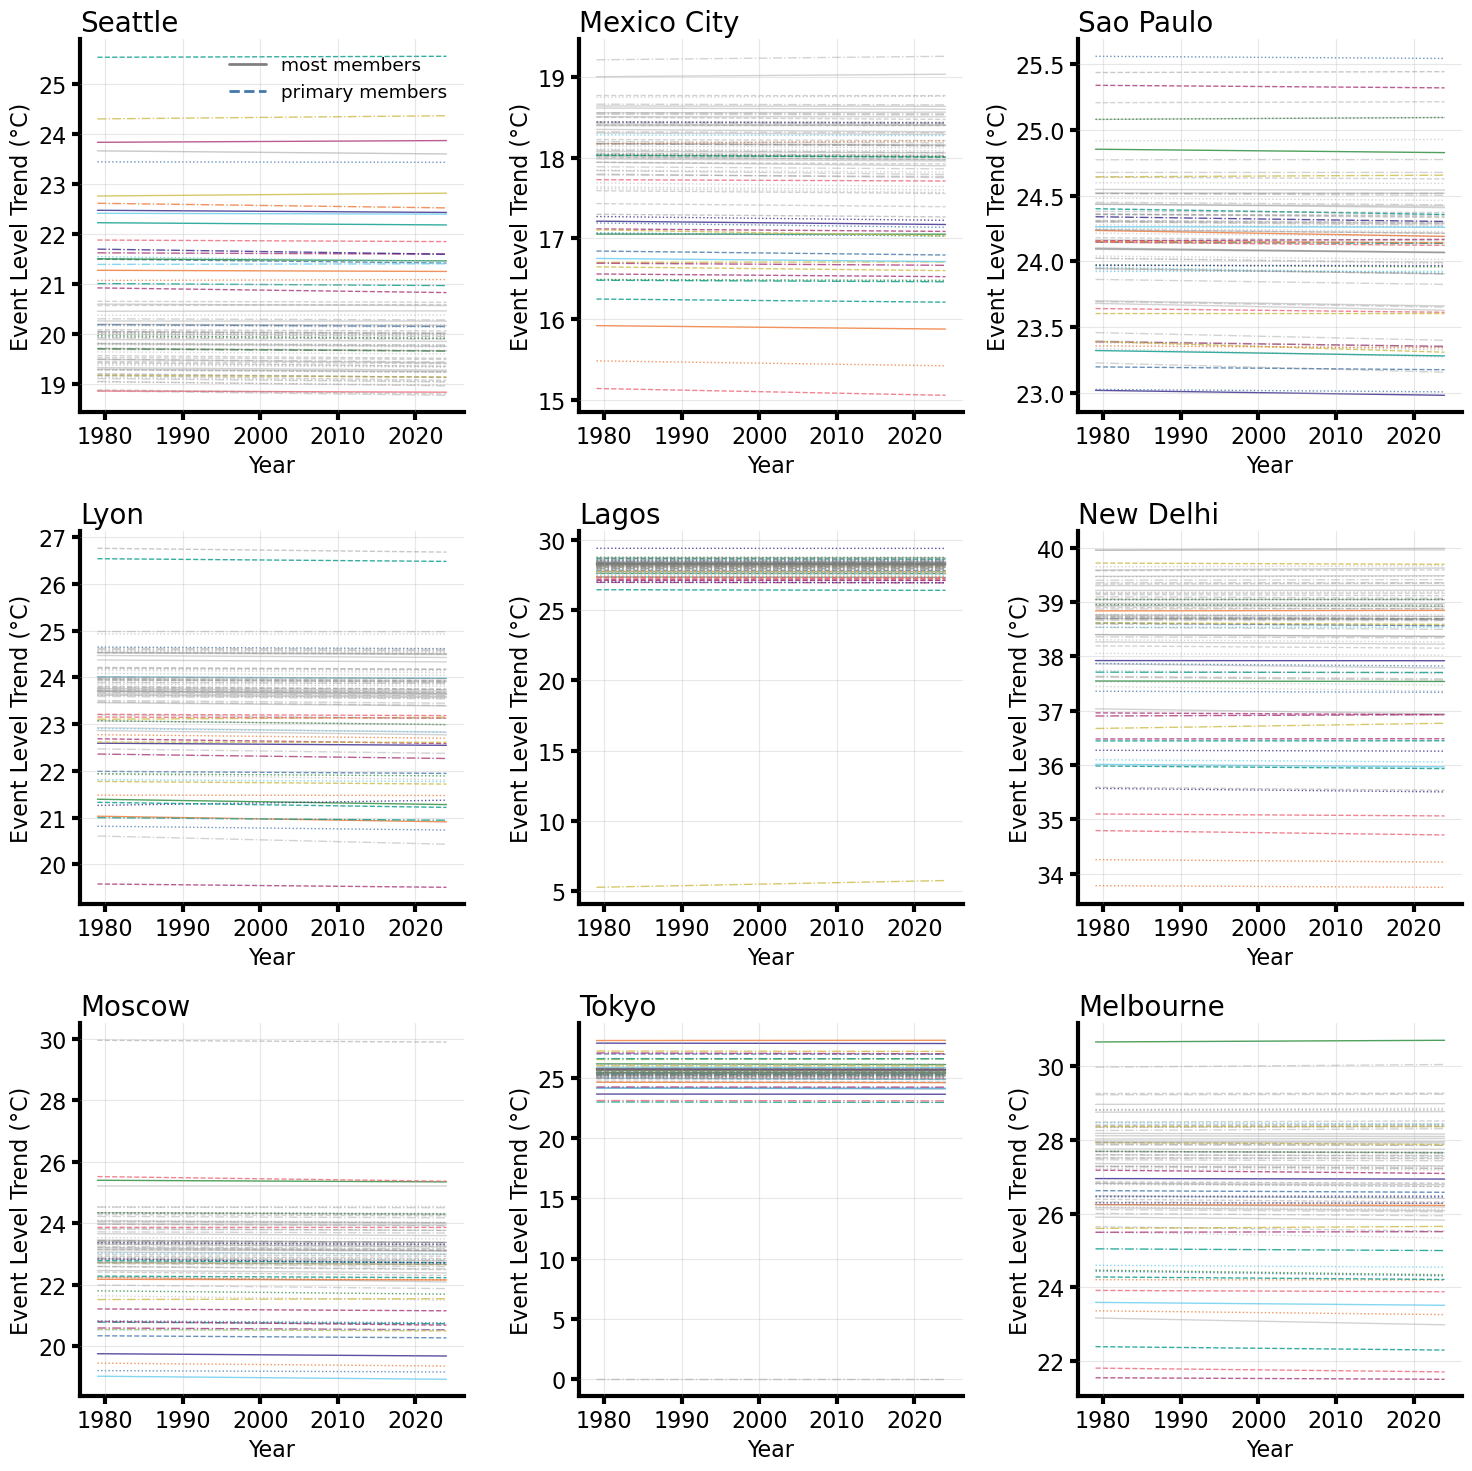

In [ ]:
# Plot event_level_trend for each location and each member
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

n_members_most = event_level_trend_most.shape[1]
n_members_prim = event_level_trend_prim.shape[1]

for edx, loc in enumerate(event_info.keys()):
    ax = axes[edx]
    for idx in range(max(n_members_most, n_members_prim)):
        if idx < n_members_most:
            trend_most = event_level_trend_most[edx, idx, :]
            if not np.all(np.isnan(trend_most)):
                ax.plot(years, trend_most, alpha=0.35, color='grey', linewidth=1)

        if idx < n_members_prim:
            trend_prim = event_level_trend_prim[edx, idx, :]
            if not np.all(np.isnan(trend_prim)):
                c = colors[idx % len(colors)]
                ax.plot(years, trend_prim, alpha=0.8, color=c, linewidth=1)

    ax.set_title(f"{loc}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Event Level Trend (°C)")
    ax.grid(True, alpha=0.3)

# add legend for the first subplot only
axes[0].plot([], [], color='grey', linewidth=2, label='most members')
axes[0].plot([], [], color=colors[0], linewidth=2, label='primary members')
axes[0].legend(loc='best', fontsize='small')

plt.tight_layout()
#if save_figs:
    #fig.savefig(make_figure_filename("event_level_trends_most_and_prim_members.png"), dpi=300, bbox_inches='tight')
plt.show()